In [1]:
import pandas as pd
seeds = pd.read_csv(r'C:\Users\Tharun37\OneDrive\Desktop\ms ml\seeds.csv', delimiter = ",", header = 'infer')
print(seeds.head())

    area  perimeter  compactness  kernel_length  kernel_width  \
0  15.26      14.84       0.8710          5.763         3.312   
1  14.88      14.57       0.8811          5.554         3.333   
2  14.29      14.09       0.9050          5.291         3.337   
3  13.84      13.94       0.8955          5.324         3.379   
4  16.14      14.99       0.9034          5.658         3.562   

   asymmetry_coefficient  groove_length  species  
0                  2.221          5.220        0  
1                  1.018          4.956        0  
2                  2.699          4.825        0  
3                  2.259          4.805        0  
4                  1.355          5.175        0  


In [2]:
features = seeds[seeds.columns[0:6]]
print(features.sample(10))

      area  perimeter  compactness  kernel_length  kernel_width  \
205  12.19      13.20       0.8783          5.137         2.981   
186  11.81      13.45       0.8198          5.413         2.716   
33   13.94      14.17       0.8728          5.585         3.150   
29   13.45      14.02       0.8604          5.516         3.065   
176  11.26      13.01       0.8355          5.186         2.710   
41   13.50      13.85       0.8852          5.351         3.158   
14   13.74      14.05       0.8744          5.482         3.114   
149  10.79      12.93       0.8107          5.317         2.648   
169  11.24      13.00       0.8359          5.090         2.715   
141  13.32      13.94       0.8613          5.541         3.073   

     asymmetry_coefficient  
205                  3.631  
186                  4.898  
33                   2.124  
29                   3.531  
176                  5.335  
41                   2.249  
14                   2.932  
149                  5.462  
1

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

scaled_features = MinMaxScaler().fit_transform(features[seeds.columns[0:6]])
pca = PCA(n_components = 2).fit(scaled_features)
features_2d = pca.transform(scaled_features)
print(features_2d[0:10])

[[ 0.11883593 -0.09382469]
 [ 0.0696878  -0.31077233]
 [-0.03499184 -0.37044705]
 [-0.06582089 -0.36365235]
 [ 0.32594892 -0.37695797]
 [-0.02455447 -0.31060184]
 [-0.00769646 -0.07594931]
 [-0.05646955 -0.26696284]
 [ 0.38196305 -0.05149471]
 [ 0.35701044 -0.17697998]]


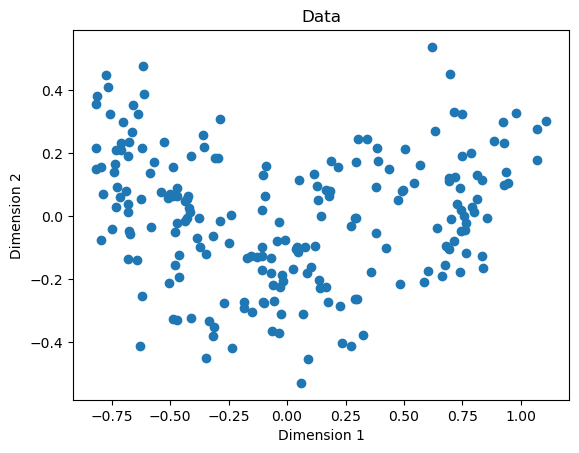

In [4]:
import matplotlib.pyplot as plt
plt.scatter(features_2d[:,0], features_2d[:,1])
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Data")
plt.show()

C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

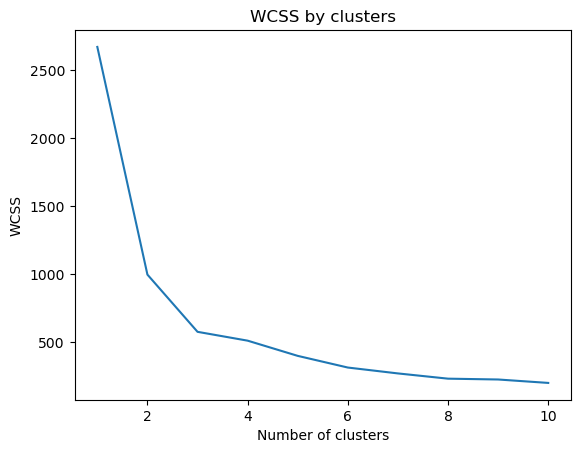

In [9]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(features.values)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS by clusters')
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")
plt.show()

In [6]:
from sklearn.cluster import KMeans
model = KMeans( n_clusters = 3, init = 'k-means++', n_init = 100, max_iter = 1000)
km_clusters = model.fit_predict(features.values)
print(km_clusters)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 2 2 2 2 2 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 2 2 2 2 1 2 2 2 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0]


C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


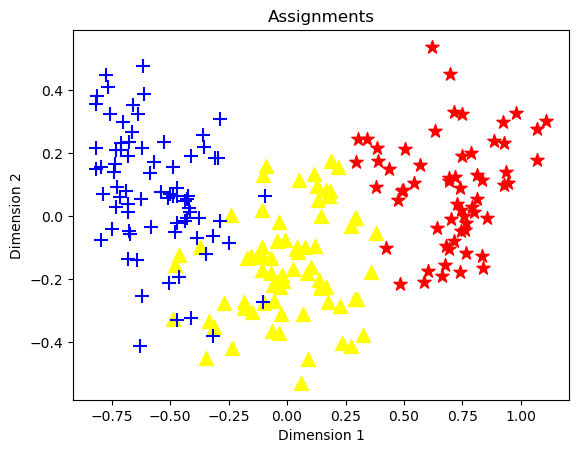

In [9]:
import matplotlib.pyplot as plt

def plot_clusters(samples, clusters):
    col_dic = {0:'blue', 1:'red', 2:'yellow'}
    mrk_dic = {0:'+', 1:'*', 2:'^'}
    colors = [col_dic[x] for x in clusters]
    markers = [mrk_dic[x] for x in clusters]
    for sample in range(len(clusters)):
        plt.scatter(samples[sample][0], samples[sample][1], color = colors[sample], marker = markers[sample], s=100)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("Assignments")
    plt.show()
plot_clusters(features_2d, km_clusters)

In [10]:
from sklearn.metrics import silhouette_score
score = silhouette_score(features.values, km_clusters)
print("Silhouette Score : ",score)

Silhouette Score :  0.4747283742378662


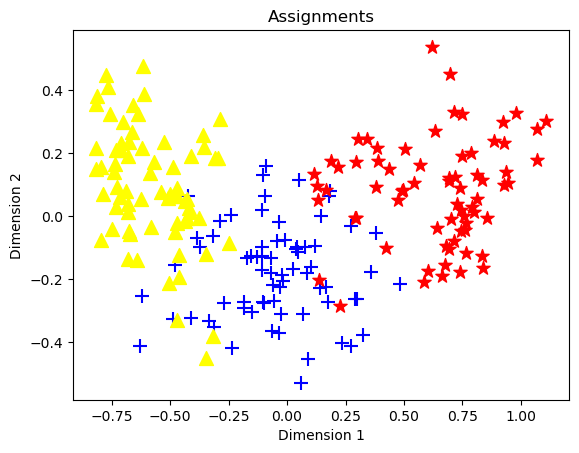

In [11]:
seed_species = seeds[seeds.columns[7]]
plot_clusters(features_2d, seed_species.values)

In [12]:
from sklearn.cluster import AgglomerativeClustering
agg_model = AgglomerativeClustering(n_clusters = 3)
agg_clusters = agg_model.fit_predict(features.values)
print(agg_clusters)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 1
 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2 2 2 2 2 2 2 2]


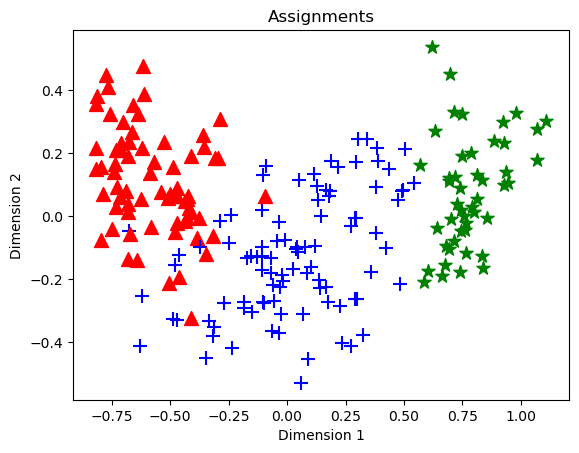

In [14]:
def plot_clusters(samples, clusters):
    col_dic = {0:'blue', 1:'green', 2:'red'}
    mrk_dic = {0:'+', 1:'*', 2:'^'}
    colors = [col_dic[x] for x in clusters]
    markers = [mrk_dic[x] for x in clusters]
    for sample in range(len(clusters)):
        plt.scatter(samples[sample][0], samples[sample][1], color = colors[sample], marker = markers[sample], s=100)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("Assignments")
    plt.show()
plot_clusters(features_2d, agg_clusters)

In [15]:
s_score = silhouette_score(features.values, agg_clusters)
print("Silhouette_score for agg_model : ",s_score)

Silhouette_score for agg_model :  0.4217795389736575
